# Pricing the run before launch, part 1: data quality and EDA

This project asks whether I can predict what a scientific solver run will cost before
launching it, and turn that into better scheduling. The raw material is my own research
computing telemetry: 2,127 solver runs collected across three codebases
(a continuum Hartree-Fock solver and two lattice mean-field solvers), plus 9,458
residual-trace rows and 78 batch-scheduler requests.

The dataset is telemetry only. The physics payloads never leave the private research
repos; the export is gated by a column whitelist, forbidden-pattern scans and salted
opaque ids (see `export/schema.py` and `tests/test_leak_audit.py`).

This notebook is the audit and exploration pass. The analysis decisions are recorded
inline where they come up, since they shape everything in part 2 (the cost model).

In [1]:
%matplotlib inline
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt, pathlib
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

ROOT = pathlib.Path().resolve()
while not (ROOT / "data").exists():
    ROOT = ROOT.parent

con = duckdb.connect()
for t in ("runs", "iterations", "requests"):
    con.execute(f"CREATE OR REPLACE VIEW {t} AS SELECT * FROM read_parquet('{ROOT/'data'/(t+'.parquet')}')")
runs = con.execute("SELECT * FROM runs").df()

for t in ("runs", "iterations", "requests"):
    print(f"{t:12s} {con.execute(f'SELECT count(*) FROM {t}').fetchone()[0]:>6,} rows")

runs          2,127 rows
iterations    9,458 rows
requests         78 rows


## 1. What each source contributed

One GROUP BY before anything else, to see where the data and the compute actually live.

In [2]:
con.execute("""
SELECT source,
       count(*)                                    AS runs,
       round(sum(wall_minutes)/60, 1)              AS wall_hours,
       count(*) FILTER (WHERE converged)           AS converged,
       count(*) FILTER (WHERE status = 'unknown')  AS status_unknown,
       count(*) FILTER (WHERE has_trace)           AS with_trace
FROM runs GROUP BY source ORDER BY runs DESC
""").df()

,source,runs,wall_hours,converged,status_unknown,with_trace
0,lattice_scf_v2,1049,132.8,137,840,104
1,continuum_scf,956,508.3,570,366,0
2,lattice_scf,122,2.5,106,0,118


Three sources with very different characters. `continuum_scf` holds most of the compute,
about 508 of the 644 total wall-hours. `lattice_scf_v2` has the most rows, but 840 of
them carry `status = 'unknown'`, and nearly all of those turn out to be seconds-long
restricted evaluations with no iteration record. They are a different population, not
failed runs, and I treat them accordingly below. Residual traces exist only for the
lattice sources, so anything trace-based is a lattice-only story.

## 2. Data quality

Four issues surfaced while building the warehouse. Each one gets a decision here,
because each one changes what part 2 is allowed to do.

### 2.1 Missingness follows the source

Fraction of missing values per column, split by source:

In [3]:
runs.groupby("source").apply(
    lambda g: g.isna().mean().round(2), include_groups=False
).T

source,continuum_scf,lattice_scf,lattice_scf_v2
run_id,0.00,0.0,0.00
campaign,0.00,0.0,0.00
cell_id,0.02,0.0,0.00
machine,0.00,0.0,0.00
seed_family,0.12,0.0,0.21
seed_origin,0.00,0.0,0.00
mixing,0.00,0.0,0.00
tol,0.00,0.0,0.86
max_iter,0.01,0.0,0.86
workers,1.00,0.0,0.14


None of this is random missingness, it is structural: each solver logs what it has.
`workers` was never recorded for continuum, `tol` and `max_iter` are absent from 86% of
lattice-v2 rows (the restricted stubs again), and the twist grid simply does not exist
for the continuum solver.

**Decision.** I sort columns by when they are knowable, not only by coverage. Model
features must be known before launch: `source`, `seed_family`, `grid_k`, `basis_nharm`,
`mixing`, `tol`, `max_iter`, `machine`. The outcome columns (`n_iter`, `converged`,
`status`, `final_residual`) are labels and diagnostics, never features, otherwise the
model would be reading the answer off the run it is supposed to predict. Ids and file
timestamps are dropped, and `campaign` is reserved for the train/test split.

### 2.2 Censored runs

A run that stops exactly at `n_iter == max_iter` was truncated by its budget, so its
recorded cost is a lower bound on the true cost. Counting them is not enough, what
matters is how much compute sits inside them:

In [4]:
con.execute("""
SELECT source,
       count(*) FILTER (WHERE n_iter >= max_iter)                       AS censored,
       count(*)                                                         AS with_budget,
       round(100.0*count(*) FILTER (WHERE n_iter>=max_iter)/count(*),1) AS censored_pct,
       round(sum(wall_minutes) FILTER (WHERE n_iter>=max_iter)/60,1)    AS censored_wall_hrs,
       round(sum(wall_minutes)/60,1)                                    AS total_wall_hrs
FROM runs WHERE n_iter IS NOT NULL AND max_iter IS NOT NULL
GROUP BY source ORDER BY censored_pct DESC
""").df()

,source,censored,with_budget,censored_pct,censored_wall_hrs,total_wall_hrs
0,lattice_scf_v2,49,146,33.6,61.7,93.0
1,lattice_scf,16,122,13.1,0.2,2.5
2,continuum_scf,20,831,2.4,30.7,495.1


For continuum this is 2.4% of runs, ignorable. For lattice-v2 it is a third of the runs
holding roughly two thirds of that source's wall-hours, which is far too much to drop
silently, and dropping it would bias cost estimates low in exactly the expensive tail
where a walltime policy operates.

**Decision.** Keep censored runs with an `is_censored` flag. The point-prediction model
trains on uncensored labels only, and quantile analyses treat flagged rows as lower
bounds. If the censored tail ever starts driving the headline numbers, the upgrade path
is a proper survival treatment.

### 2.3 Apportioned wall-times

472 continuum rows come from multi-seed jobs where one job-level timer was split across
the seed arms in proportion to iterations used. A documented approximation, reasonable
on average, but softer than a per-run measurement. They concentrate in the largest
campaigns:

In [5]:
con.execute("""
SELECT campaign, count(*) AS rows
FROM runs WHERE source = 'continuum_scf'
GROUP BY campaign ORDER BY rows DESC LIMIT 6
""").df()

,campaign,rows
0,campaign_12,320
1,campaign_01,185
2,campaign_13,140
3,campaign_09,112
4,campaign_02,105
5,campaign_03,28


**Decision.** Keep them, and stress-test in part 2 by refitting without the dominant
block. A future rebuild should tag them with an `is_apportioned` column at parse time so
the exact subset can be isolated.

### 2.4 The requests table will not join, and does not need to

The runs and requests tables were anonymized from different raw strings (directory names
vs sbatch job names), so shared campaign codes cannot be assumed. Checking:

In [6]:
shared = con.execute("""
SELECT count(*) FROM (
    SELECT DISTINCT campaign FROM runs
    INTERSECT
    SELECT DISTINCT campaign FROM requests)
""").fetchone()[0]
print(f"distinct campaigns: runs {con.execute('SELECT count(DISTINCT campaign) FROM runs').fetchone()[0]}, "
      f"requests {con.execute('SELECT count(DISTINCT campaign) FROM requests').fetchone()[0]}, shared {shared}")
print("\nrequests columns:", ", ".join(con.execute("DESCRIBE requests").df().column_name))

distinct campaigns: runs 34, requests 78, shared 1

requests columns: request_id, campaign, machine, requested_walltime_min, nodes, cores, partition


One shared code out of 34 and 78, and no timestamp column to join on instead.

**Decision.** No row-level join. It turns out none is needed: the walltime question in
part 2 compares the distribution of requested time against the distribution of realized
cost per machine, which is two GROUP BYs. If a later question genuinely needs row-level
links, the fix is a small hand-curated campaign map, not a fuzzy join.

## 3. What makes a run expensive

### 3.1 The shape of cost

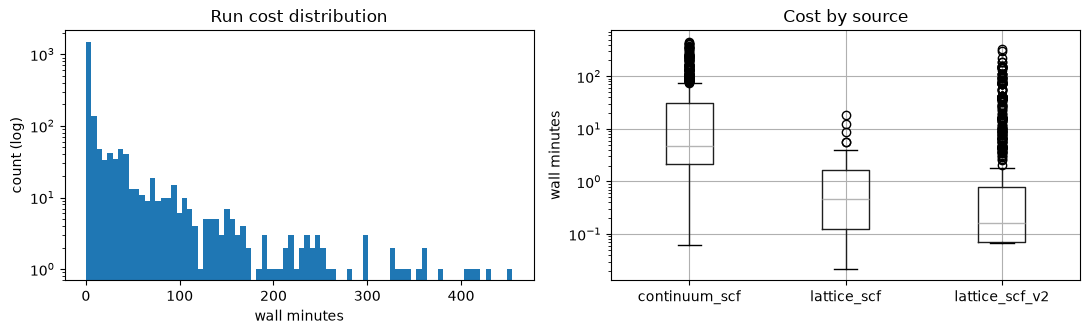

In [7]:
timed = runs.dropna(subset=["wall_minutes"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
timed["wall_minutes"].plot.hist(bins=80, log=True, ax=ax[0])
ax[0].set(xlabel="wall minutes", ylabel="count (log)", title="Run cost distribution")
timed.boxplot(column="wall_minutes", by="source", ax=ax[1])
ax[1].set_yscale("log"); ax[1].set(title="Cost by source", xlabel=""); ax[1].set_ylabel("wall minutes")
plt.suptitle(""); plt.tight_layout()

Costs span four orders of magnitude, from a few seconds to several hours, with a long
right tail, and the sources sit at different levels. That settles the modeling target:
`log(wall_minutes)`, so that a 2x error means the same thing for a 30-second run and a
3-hour run, and `source` stays in the feature set.

### 3.2 Seed families: a real effect, with a confounding check

The starting guess handed to the solver is a scheduling knob, if some seed families
reliably converge cheaper. Raw ranking first (families with at least 20 runs):

In [8]:
(runs.dropna(subset=["n_iter"])
     .groupby("seed_family")["n_iter"].agg(["count", "median"])
     .query("count >= 20").sort_values("median", ascending=False).head(10))

,count,median
seed_family,,
ohaus,55,238.0
skx_str,62,131.0
skx,175,103.0
wigner,34,99.5
cycloid,174,99.0
overhauser_warmstart,118,96.5
skx_strong,118,96.0
stripe,36,84.5
random,40,80.0


The spread is large, but this table mixes campaigns, and expensive campaigns may simply
have used particular seeds. The cleaner question is whether the effect survives with the
campaign held fixed:

In [9]:
counts = (runs.dropna(subset=["n_iter"])
              .groupby(["campaign", "seed_family"]).size().rename("n").reset_index())
target = counts[counts.n >= 8].groupby("campaign").size().idxmax()
print(f"within {target}:")
(runs.query("campaign == @target").dropna(subset=["n_iter"])
     .groupby("seed_family")["n_iter"].agg(["count", "median"])
     .query("count >= 8").sort_values("median", ascending=False))

within campaign_33:


,count,median
seed_family,,
random,30,55.0
uniform_fm,13,33.0
double_q12_collinear_orthogonal,9,12.0
single_q1_collinear,9,10.0
triple_q_tetrahedral_orthogonal,11,10.0
double_q12_collinear_parallel,15,8.0
triple_q_coplanar_120,15,8.0
pm_unpolarized,16,1.0


Inside a single campaign the cheapest family converges in a median of 1 iteration and
the priciest needs 55, so the seed effect is real, not just campaign confounding. One
caution for later: seed vocabularies are mostly campaign-specific (this campaign's
families barely appear elsewhere), so a fair seed ranking is a within-source,
within-campaign statement.

### 3.3 Cost scales as a power of the grid

In [10]:
g = con.execute("""
SELECT grid_k, count(*) AS n, round(median(wall_minutes),3) AS med_min,
       round(median(n_iter),0) AS med_iter
FROM runs WHERE source='continuum_scf' AND grid_k IS NOT NULL AND wall_minutes IS NOT NULL
GROUP BY grid_k ORDER BY grid_k
""").df()
print(g.to_string(index=False))
p, _ = np.polyfit(np.log(g.grid_k), np.log(g.med_min), 1)
print(f"\nfitted exponent: cost ~ grid_k^{p:.1f}")

 grid_k   n  med_min  med_iter
    8.0 140    0.478      84.0
   12.0 338    3.106     101.0
   16.0 347   43.355     122.0

fitted exponent: cost ~ grid_k^6.4


Median cost climbs from 0.5 to 43 minutes as the k-grid goes from 8 to 16, an exponent
near 6.4, while the median iteration count barely moves (84 to 122). The blow-up is
per-iteration work, not extra iterations, which makes `grid_k` the single most
informative physical feature a cost model can have.

### 3.4 Where the hours actually went

In [11]:
con.execute("""
SELECT source, converged, count(*) AS n, round(sum(wall_minutes)/60,1) AS wall_hrs,
       round(100.0*sum(wall_minutes)/sum(sum(wall_minutes)) OVER (PARTITION BY source),1) AS pct_of_source
FROM runs WHERE wall_minutes IS NOT NULL
GROUP BY source, converged ORDER BY source, converged
""").df()

,source,converged,n,wall_hrs,pct_of_source
0,continuum_scf,False,386,221.5,43.6
1,continuum_scf,True,563,286.8,56.4
2,lattice_scf,False,16,0.2,9.4
3,lattice_scf,True,106,2.3,90.6
4,lattice_scf_v2,False,77,91.0,68.5
5,lattice_scf_v2,True,135,39.1,29.4
6,lattice_scf_v2,<NA>,818,2.7,2.0


About 44% of the continuum source's wall-hours were burned by runs that never converged.
That single number is the business case for this project: a predictor that prices runs,
and flags likely non-convergence before launch, is attacking nearly half the bill.

### 3.5 Convergence trajectories

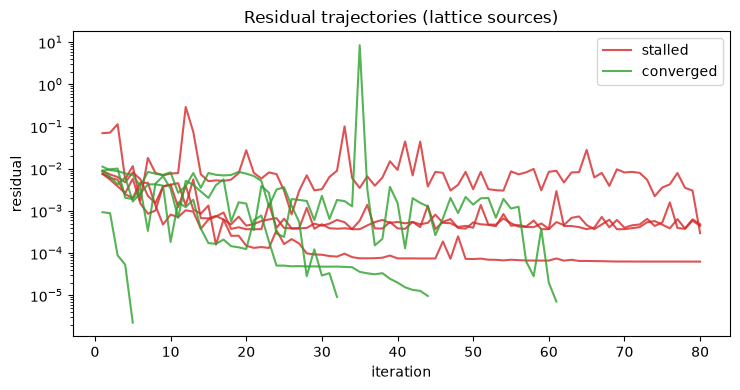

In [12]:
ids = con.execute("""
SELECT run_id, converged FROM runs
WHERE has_trace AND converged IS NOT NULL
QUALIFY row_number() OVER (PARTITION BY converged ORDER BY run_id) <= 4
""").df()
fig, ax = plt.subplots(figsize=(7.5, 4))
for _, r in ids.iterrows():
    tr = con.execute("SELECT step, residual FROM iterations WHERE run_id=? ORDER BY step", [r.run_id]).df()
    ax.semilogy(tr.step, tr.residual, color=("tab:green" if r.converged else "tab:red"),
                alpha=.8, label=("converged" if r.converged else "stalled"))
h, l = ax.get_legend_handles_labels()
ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys())
ax.set(xlabel="iteration", ylabel="residual", title="Residual trajectories (lattice sources)")
plt.tight_layout()

Converged runs walk the residual down steadily, stalled ones plateau and then burn the
rest of their budget. The early slope of a trace is an obvious signal for an in-flight
kill rule. I am keeping that out of scope for part 2, since traces exist only for the
lattice sources, but it is the natural part 3 extension.

### 3.6 Requested vs realized walltime

In [13]:
print("requested, per machine:")
print(con.execute("""
  SELECT machine, count(*) AS reqs, round(median(requested_walltime_min)) AS med_req_min
  FROM requests GROUP BY machine ORDER BY reqs DESC""").df().to_string(index=False))
print("\nrealized, per machine:")
print(con.execute("""
  SELECT machine, count(*) AS runs, round(median(wall_minutes),1) AS med_min,
         round(quantile_cont(wall_minutes, 0.95),1) AS p95_min
  FROM runs WHERE wall_minutes IS NOT NULL GROUP BY machine ORDER BY runs DESC""").df().to_string(index=False))

requested, per machine:
   machine  reqs  med_req_min
  tillicum    56        180.0
perlmutter    22        720.0

realized, per machine:
   machine  runs  med_min  p95_min
   unknown  1624      0.4     33.6
perlmutter   345     42.8    253.8
    laptop   132      4.5     90.8


On perlmutter (the one machine both tables cover) the median request is 720 minutes
against a median realized cost near 43: a 17x cushion applied as a flat habit. Safe, but
it is exactly the kind of blanket over-reservation that a per-run prediction with a
coverage guarantee can tighten. That is part 2's second deliverable.

## 4. What carries into part 2

- Target: `log(wall_minutes)`. Features: pre-launch columns only, `campaign` reserved
  for splitting. Outcome columns stay out of the feature set.
- Split by campaign, never randomly. Runs within a campaign are near-duplicates, and a
  random split would score the model on copies of its training rows.
- 1,156 trainable rows after removing stubs and censored labels (both filters are
  post-hoc information, fine for selecting training rows, never usable as features).
- The censored tail matters for quantiles, so walltime fits treat those rows as lower
  bounds. The apportioned block gets a stress test.
- Motivation to beat: 44% of continuum compute spent on non-converged runs, and a 17x
  blanket walltime cushion.